In [25]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import random
from scipy.ndimage import gaussian_filter
from skimage import transform
import warnings
warnings.filterwarnings('ignore')
print("Librerías importadas correctamente")

Librerías importadas correctamente


In [26]:
# Rutas principales
BASE_DIR = Path("Datos/Dataset_Evolutivo_Simulado")
INPUT_DIR = BASE_DIR / "train_B"  # Imágenes segmentadas limpias
OUTPUT_DIR = BASE_DIR / "train_B_1"  # Imágenes con manchas simuladas

# Verificar que existan las carpetas
assert INPUT_DIR.exists(), f"No se encuentra la carpeta: {INPUT_DIR}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Carpeta de entrada: {INPUT_DIR}")
print(f"Carpeta de salida: {OUTPUT_DIR}")

# Contar imágenes disponibles
image_files = list(INPUT_DIR.glob("*.jpg")) + list(INPUT_DIR.glob("*.png"))
print(f"\nTotal de imágenes encontradas: {len(image_files)}")


Carpeta de entrada: Datos\Dataset_Evolutivo_Simulado\train_B
Carpeta de salida: Datos\Dataset_Evolutivo_Simulado\train_B_1

Total de imágenes encontradas: 1863


In [27]:
def generate_irregular_mask(img_shape, num_spots=3, size_range=(30, 80)):
    """
    Genera una máscara con manchas irregulares que simulan lesiones.

    Args:
        img_shape: Forma de la imagen (height, width)
        num_spots: Número de manchas a generar
        size_range: Rango de tamaño de las manchas

    Returns:
        Máscara binaria con las manchas
    """
    h, w = img_shape[:2]
    mask = np.zeros((h, w), dtype=np.float32)

    for _ in range(num_spots):
        # Posición aleatoria
        center_x = random.randint(size_range[1], w - size_range[1])
        center_y = random.randint(size_range[1], h - size_range[1])

        # Tamaño aleatorio
        radius = random.randint(size_range[0], size_range[1])

        # Crear forma irregular usando elipse deformada
        y, x = np.ogrid[:h, :w]

        # Parámetros de la elipse con deformación
        a = radius * random.uniform(0.8, 1.5)  # Semi-eje mayor
        b = radius * random.uniform(0.6, 1.2)  # Semi-eje menor
        angle = random.uniform(0, np.pi)  # Rotación

        # Aplicar rotación
        x_rot = (x - center_x) * np.cos(angle) + (y - center_y) * np.sin(angle)
        y_rot = -(x - center_x) * np.sin(angle) + (y - center_y) * np.cos(angle)

        # Crear elipse irregular
        ellipse = ((x_rot / a) ** 2 + (y_rot / b) ** 2) <= 1

        # Añadir irregularidad en los bordes
        noise = np.random.rand(h, w) > 0.7
        ellipse = ellipse | (ellipse & noise)

        mask = np.maximum(mask, ellipse.astype(np.float32))

    # Suavizar bordes para hacerlos más realistas
    mask = gaussian_filter(mask, sigma=3)

    return mask

In [28]:
def generate_pigmentation_variation(img_shape):
    """
    Genera variaciones de pigmentación para simular heterogeneidad.

    Args:
        img_shape: Forma de la imagen

    Returns:
        Mapa de variación de pigmentación
    """
    h, w = img_shape[:2]

    # Crear ruido Perlin simplificado
    scale = random.randint(30, 60)
    noise = np.random.rand(h // scale, w // scale)

    # Redimensionar y suavizar
    pigmentation = cv2.resize(noise, (w, h), interpolation=cv2.INTER_CUBIC)
    pigmentation = gaussian_filter(pigmentation, sigma=random.uniform(5, 15))

    # Normalizar entre 0.7 y 1.3 para variación moderada
    pigmentation = 0.7 + 0.6 * (pigmentation - pigmentation.min()) / (pigmentation.max() - pigmentation.min())

    return pigmentation

In [29]:
def detect_lesion_mask(image, threshold=30):
    """
    Detecta áreas que NO son piel normal (lesiones, manchas, etc.)

    Args:
        image: Imagen BGR
        threshold: Umbral de diferencia con el color de piel promedio

    Returns:
        Máscara binaria donde 1 = lesión, 0 = piel normal
    """
    # Convertir a espacio de color LAB (mejor para detectar piel)
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    # Detectar píxeles que no son tonos de piel (valores extremos)
    l_channel = lab[:, :, 0]
    a_channel = lab[:, :, 1]

    # La piel normal tiene valores L altos y A/B moderados
    # Las lesiones tienden a ser más oscuras o con tonos diferentes
    lesion_mask = (l_channel < 180) & (l_channel > 30)  # No muy claro ni muy oscuro

    # Dilatar y erosionar para limpiar ruido
    kernel = np.ones((5, 5), np.uint8)
    lesion_mask = cv2.morphologyEx(lesion_mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
    lesion_mask = cv2.morphologyEx(lesion_mask, cv2.MORPH_OPEN, kernel)

    return lesion_mask.astype(np.float32)


def add_gaussian_fog(image, mask, intensity=0.3):
    """
    Añade efecto de niebla gaussiana solo en las áreas de la máscara.

    Args:
        image: Imagen original (0-1 float)
        mask: Máscara de áreas a afectar (0-1 float)
        intensity: Intensidad de la niebla (0-1)

    Returns:
        Imagen con niebla aplicada
    """
    h, w = image.shape[:2]

    # Crear niebla con múltiples capas de ruido gaussiano
    fog = np.zeros_like(image)

    # Capa 1: Niebla general (frecuencia baja)
    fog_layer1 = np.random.randn(h, w) * 0.15
    fog_layer1 = gaussian_filter(fog_layer1, sigma=20)

    # Capa 2: Detalles medios
    fog_layer2 = np.random.randn(h, w) * 0.1
    fog_layer2 = gaussian_filter(fog_layer2, sigma=10)

    # Capa 3: Detalles finos
    fog_layer3 = np.random.randn(h, w) * 0.05
    fog_layer3 = gaussian_filter(fog_layer3, sigma=3)

    # Combinar capas
    combined_fog = fog_layer1 + fog_layer2 + fog_layer3

    # Normalizar y aplicar a cada canal con variación de color
    for c in range(3):
        color_variation = random.uniform(0.9, 1.1)
        fog[:, :, c] = combined_fog * color_variation * intensity

    # Aplicar solo en las áreas de la máscara
    mask_3d = np.stack([mask] * 3, axis=-1)
    result = image + fog * mask_3d

    return np.clip(result, 0, 1)


def add_salt_pepper_noise(image, mask, amount=0.02):
    """
    Añade ruido sal y pimienta solo en las áreas de la máscara.

    Args:
        image: Imagen original (0-1 float)
        mask: Máscara de áreas a afectar (0-1 float)
        amount: Cantidad de ruido (proporción de píxeles afectados)

    Returns:
        Imagen con ruido aplicado
    """
    result = image.copy()
    h, w = image.shape[:2]

    # Crear máscara de píxeles a afectar (solo donde mask > 0.3)
    affected_area = mask > 0.3
    num_affected = int(np.sum(affected_area) * amount)

    if num_affected == 0:
        return result

    # Obtener coordenadas de área afectada
    coords = np.where(affected_area)

    # Seleccionar píxeles aleatorios
    indices = np.random.choice(len(coords[0]), min(num_affected, len(coords[0])), replace=False)

    for idx in indices:
        y, x = coords[0][idx], coords[1][idx]

        # 50% sal (blanco), 50% pimienta (negro)
        if random.random() < 0.5:
            result[y, x] = 1.0  # Sal (blanco)
        else:
            result[y, x] = 0.0  # Pimienta (negro)

    return result


def add_dark_spots(image, mask, num_spots=5, size_range=(3, 15)):
    """
    Añade manchas oscuras pequeñas tipo hiperpigmentación.

    Args:
        image: Imagen original (0-1 float)
        mask: Máscara de áreas a afectar
        num_spots: Número de manchas
        size_range: Rango de tamaño de manchas

    Returns:
        Imagen con manchas oscuras
    """
    result = image.copy()
    h, w = image.shape[:2]

    # Obtener áreas donde aplicar manchas
    affected_coords = np.where(mask > 0.5)

    if len(affected_coords[0]) == 0:
        return result

    for _ in range(num_spots):
        # Seleccionar posición aleatoria en área afectada
        idx = random.randint(0, len(affected_coords[0]) - 1)
        center_y = affected_coords[0][idx]
        center_x = affected_coords[1][idx]

        # Tamaño aleatorio
        radius = random.randint(size_range[0], size_range[1])

        # Crear mancha con gradiente suave
        y, x = np.ogrid[:h, :w]
        distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        spot_mask = np.exp(-(distance**2) / (2 * (radius/2)**2))

        # Oscurecer la zona (tonos marrones/grises)
        darkening_factor = random.uniform(0.3, 0.7)
        color_tint = np.array([random.uniform(0.6, 0.9),
                               random.uniform(0.5, 0.8),
                               random.uniform(0.4, 0.7)])

        for c in range(3):
            result[:, :, c] = result[:, :, c] * (1 - spot_mask * darkening_factor) + \
                             color_tint[c] * spot_mask * darkening_factor * image[:, :, c]

    return result


def apply_lesion_simulation(image, evolution_months=6):
    """
    Aplica simulación realista de lesión cutánea con manchas sutiles tipo niebla.

    Args:
        image: Imagen segmentada (numpy array RGB)
        evolution_months: Meses de evolución simulados (afecta la intensidad)

    Returns:
        Imagen con mancha simulada
    """
    img = image.copy().astype(np.float32) / 255.0

    # Parámetros basados en meses de evolución
    evolution_factor = min(evolution_months / 12.0, 1.0)

    # 1. Detectar áreas de lesión existentes (áreas no piel)
    lesion_mask = detect_lesion_mask(image)

    # 2. Generar máscara adicional de manchas irregulares (más manchas)
    num_spots = random.randint(5, 10)  # Aumentado de 2-5 a 5-10
    size_range = (int(15 + 40 * evolution_factor), int(40 + 100 * evolution_factor))
    additional_mask = generate_irregular_mask(img.shape, num_spots=num_spots, size_range=size_range)

    # Combinar máscaras (priorizar lesiones detectadas)
    combined_mask = np.maximum(lesion_mask * 0.8, additional_mask * 0.6)  # Mayor intensidad
    combined_mask = gaussian_filter(combined_mask, sigma=5)  # Suavizar transiciones

    # 3. Aplicar niebla gaussiana (más intensa)
    fog_intensity = random.uniform(0.25, 0.5) * evolution_factor  # Aumentado de 0.15-0.35
    result = add_gaussian_fog(img, combined_mask, intensity=fog_intensity)

    # 4. Añadir manchas oscuras pequeñas (muchas más)
    num_dark_spots = int(15 + 30 * evolution_factor)  # Aumentado de 5+10
    result = add_dark_spots(result, combined_mask, num_spots=num_dark_spots, size_range=(2, 15))

    # 5. Añadir ruido sal y pimienta más visible
    noise_amount = random.uniform(0.005, 0.015) * evolution_factor  # Aumentado de 0.001-0.005
    result = add_salt_pepper_noise(result, combined_mask, amount=noise_amount)

    # 6. Añadir variación de pigmentación más pronunciada
    pigmentation = generate_pigmentation_variation(img.shape)
    pigmentation_intensity = 0.25 * evolution_factor  # Aumentado de 0.15
    mask_3d = np.stack([combined_mask] * 3, axis=-1)
    pigmentation_3d = np.stack([pigmentation] * 3, axis=-1)

    # Oscurecer ligeramente con variación
    darkening = 1.0 - (pigmentation_3d * pigmentation_intensity * mask_3d)
    result = result * darkening

    # 7. Ajustar ligeramente el contraste en áreas afectadas
    result = np.clip(result, 0, 1)

    # Convertir de vuelta a uint8
    result = (result * 255).astype(np.uint8)

    return result


print("Funciones de simulación definidas correctamente")


Funciones de simulación definidas correctamente


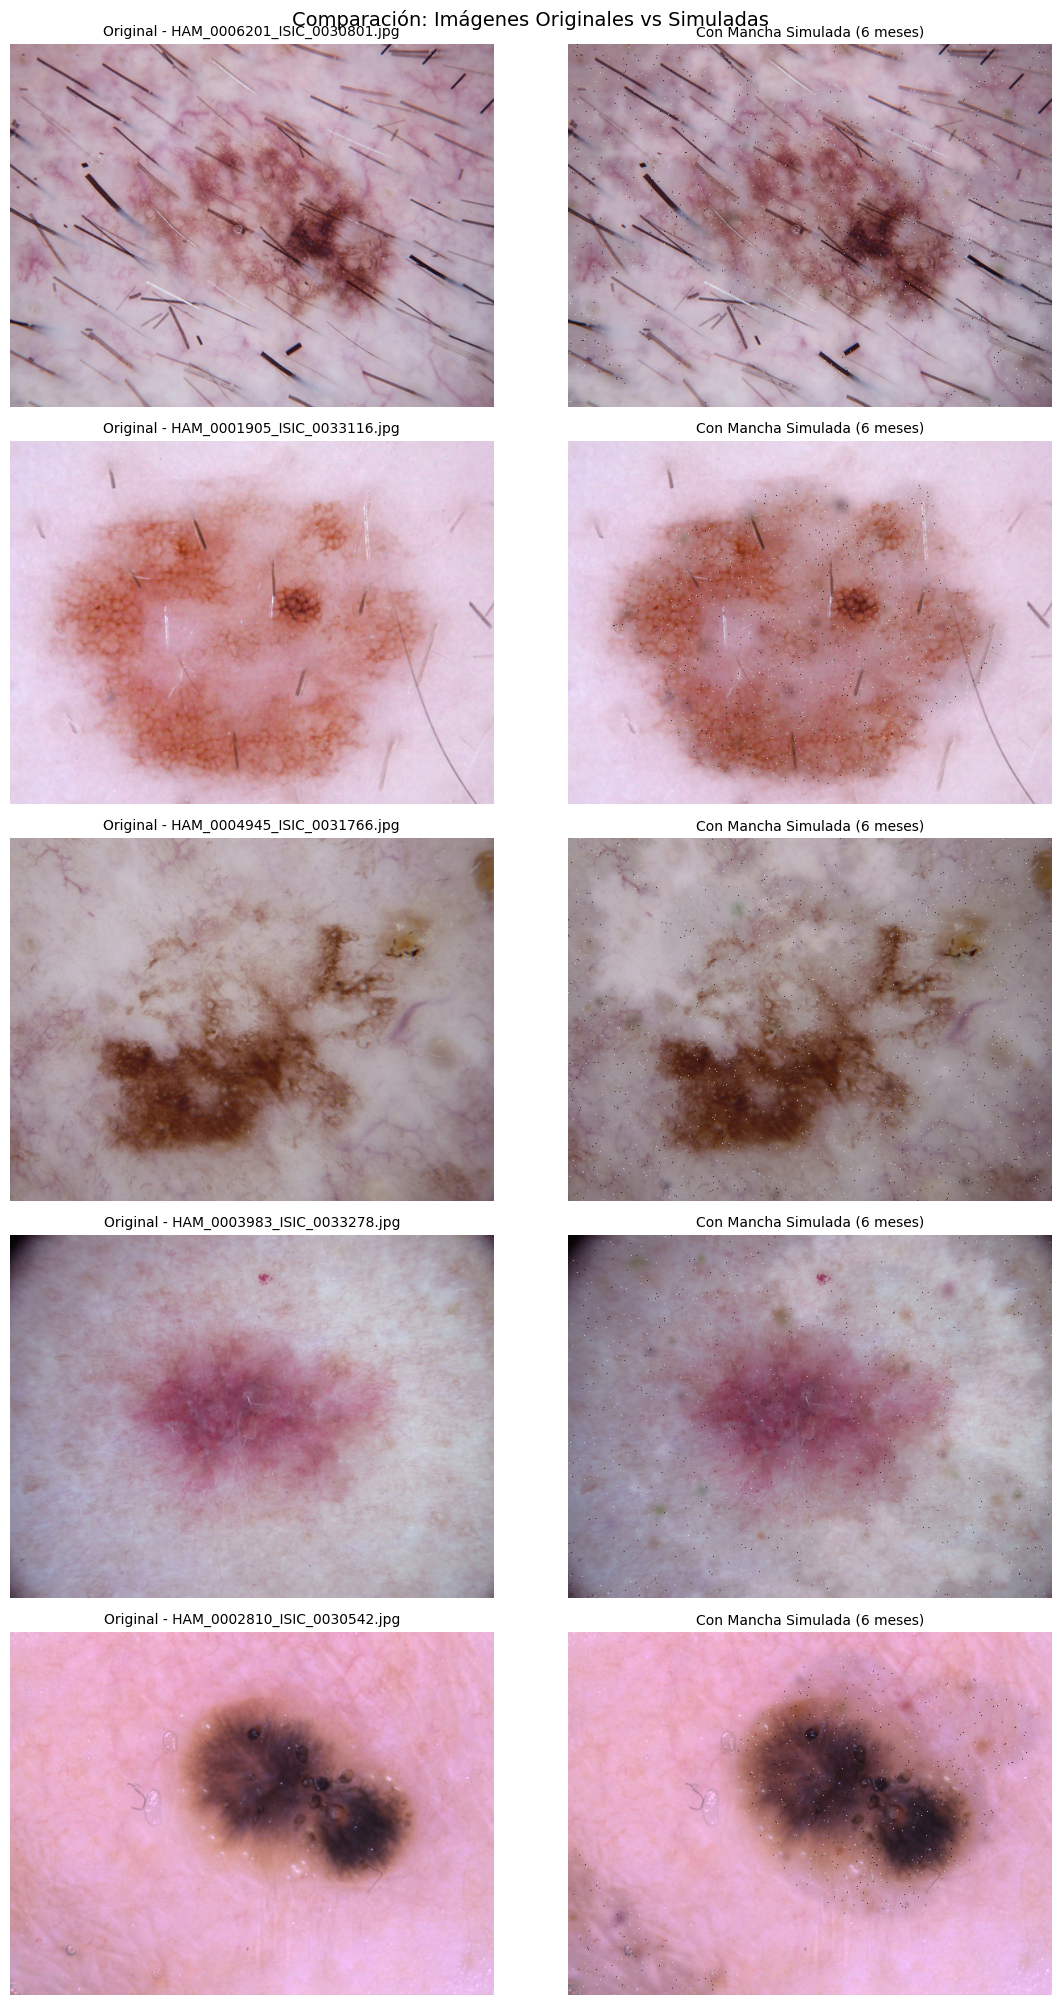


Visualización completada


In [30]:
# Seleccionar 5 imágenes aleatorias para visualizar
sample_images = random.sample(image_files, min(5, len(image_files)))

fig, axes = plt.subplots(5, 2, figsize=(12, 20))

for idx, img_path in enumerate(sample_images):
    # Leer imagen original
    original = cv2.imread(str(img_path))
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    # Aplicar simulación
    simulated = apply_lesion_simulation(original, evolution_months=6)

    # Mostrar comparación
    axes[idx, 0].imshow(original)
    axes[idx, 0].set_title(f"Original - {img_path.name}", fontsize=10)
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(simulated)
    axes[idx, 1].set_title("Con Mancha Simulada (6 meses)", fontsize=10)
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.suptitle("Comparación: Imágenes Originales vs Simuladas", fontsize=14, y=1.0)
plt.show()

print("\nVisualización completada")